<a href="https://colab.research.google.com/github/rithishdev/DL_Lab/blob/main/DL_Exp01_PartA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (20640, 10)
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


/tmp/ipykernel_5118/2606484757.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing[col].fillna(housing[col].median(), inplace=True)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 56041721856.0000 - mae: 206782.4531 - val_loss: 56386953216.0000 - val_mae: 206906.6875
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 54252220416.0000 - mae: 203069.5781 - val_loss: 52750041088.0000 - val_mae: 199352.4375
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 48422899712.0000 - mae: 190534.3281 - val_loss: 44645437440.0000 - val_mae: 181395.9062
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 38746415104.0000 - mae: 167688.8125 - val_loss: 33755555840.0000 - val_mae: 154340.4062
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 27788488704.0000 - mae: 137811.6094 - val_loss: 23160279040.0000 - val_mae: 123165.4531
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 18547019776.0000 - mae: 108406.4766 - val_loss: 15486396416.0000 - val_mae: 96349.6719
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 12809369600.0000 - mae: 87263.9141 - val_loss: 114850

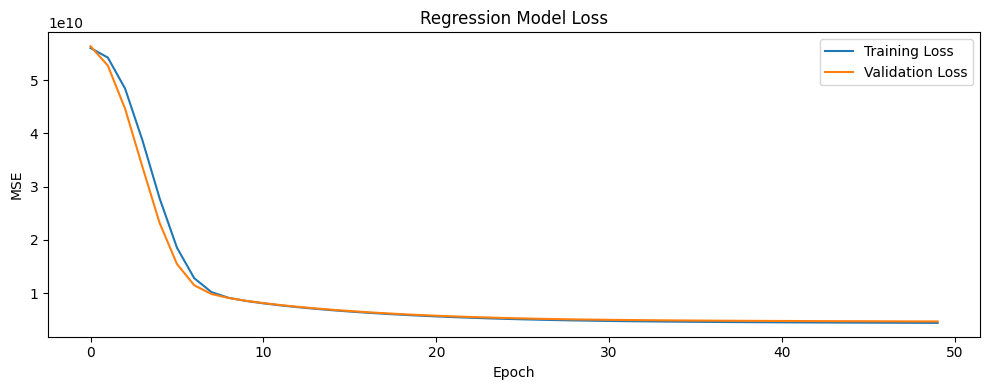

In [ ]:
# PART A: ANN FOR REGRESSION
# Dataset: California Housing Dataset
#24BAD099 - Rithish A

import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load dataset
csv_path = "housing.csv"
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"Dataset not found: {csv_path}")

housing = pd.read_csv(csv_path)
print("Dataset shape:", housing.shape)
print(housing.head())

# Handle missing values (e.g., in 'total_bedrooms')
# Impute with median as it's less sensitive to outliers than mean
for col in ['total_bedrooms']:
    if col in housing.columns:
        housing[col].fillna(housing[col].median(), inplace=True)

# Detect target column and split features/target
possible_targets = [
    "median_house_value",
    "MedHouseVal",
    "target",
    "price",
    "Price",
    "SalePrice",
]

target_column = next((column for column in possible_targets if column in housing.columns), housing.columns[-1])
X = housing.drop(columns=[target_column])
y = housing[target_column]

# If categorical columns exist, encode them safely
X = pd.get_dummies(X, drop_first=True)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build ANN model
regression_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1)
])

# Compile model
regression_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# Train model
history = regression_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

# Predict and evaluate
regression_predictions = regression_model.predict(X_test).ravel()
mse = mean_squared_error(y_test, regression_predictions)
mae = mean_absolute_error(y_test, regression_predictions)
rmse = np.sqrt(mse)

print("\nRegression Evaluation")
print("---------------------")
print("MSE :", mse)
print("MAE :", mae)
print("RMSE:", rmse)

# Optional training curves
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Regression Model Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
plt.show()